In [1]:
!cd /kaggle/working
!git clone https://github.com/goutamyg/SMAT.git

Cloning into 'SMAT'...
remote: Enumerating objects: 971, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 971 (delta 46), reused 46 (delta 36), pack-reused 905 (from 1)
Receiving objects: 100% (971/971), 1.86 MiB | 18.46 MiB/s, done.
Resolving deltas: 100% (129/129), done.


In [17]:
!cp /kaggle/input/datasets/fadyhanywadie/mobilevitv2-track-ep0300-pth-tar/MobileViTv2_Track_ep0300.pth.tar /kaggle/working/SMAT/output/checkpoints/train/mobilevitv2_track/mobilevitv2_256_128x1_ep300/SMAT_ep0300.pth.tar


In [19]:
import os, sys

WORKING_DIR = "/kaggle/working/SMAT"
DATA_DIR    = "/kaggle/input/datasets/galaxythereal/uav123-tracking-dataset"
OUTPUT_DIR  = f"{WORKING_DIR}/output"

print(f"Working dir : {WORKING_DIR}")
print(f"Data dir    : {DATA_DIR}")
print(f"Output dir  : {OUTPUT_DIR}")

Working dir : /kaggle/working/SMAT
Data dir    : /kaggle/input/datasets/galaxythereal/uav123-tracking-dataset
Output dir  : /kaggle/working/SMAT/output


In [20]:
# ── Install Python dependencies ────────────────────────────────────────────────
os.chdir(WORKING_DIR)
sys.path.insert(0, WORKING_DIR)

# Core packages needed (conda env not available on Kaggle, use pip)
!pip install -q einops timm yacs pycocotools
!pip install -q lmdb jpeg4py
!pip install -q kornia opencv-python
!pip install -q tensorboardX visdom
!pip install -q thop

print("✅ Dependencies installed")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.7 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.0 MB/s eta 0:00:00
✅ Dependencies installed


In [36]:
%cd /kaggle/working/SMAT

/kaggle/working/SMAT


In [38]:
file_path = "/kaggle/working/SMAT/lib/train/data/loader.py"

with open(file_path, "r") as f:
    text = f.read()

text = text.replace("from torch._six import string_classes", "string_classes = (str,)")

with open(file_path, "w") as f:
    f.write(text)

print("Patch applied successfully")

Patch applied successfully


In [39]:
!python tracking/create_default_local_file.py \
--workspace_dir . \
--data_dir ./data \
--save_dir ./output

2026-03-07 19:11:00.059891: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772910660.085401     340 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772910660.092952     340 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772910660.113464     340 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772910660.113516     340 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772910660.113520     340 computation_placer.cc:177] computation placer alr

In [41]:
path = "lib/test/evaluation/local.py"

text = open(path).read()
text = text.replace(
"self.trackingnet_path = ''",
"""self.trackingnet_path = ''
        self.uav_path = "/kaggle/input/datasets/galaxythereal/uav123-tracking-dataset"
"""
)

open(path,"w").write(text)

1837

In [42]:
!ls lib/test/evaluation/


avistdataset.py   lasotextdataset.py		  tc128cedataset.py
data.py		  lasotextensionsubsetdataset.py  tc128dataset.py
datasets.py	  lasot_lmdbdataset.py		  tnl2kdataset.py
environment.py	  local.py			  tracker_got10kval.py
got10kdataset.py  nfsdataset.py			  tracker.py
__init__.py	  otbdataset.py			  trackingnetdataset.py
itbdataset.py	  __pycache__			  uavdataset.py
lasotdataset.py   running.py			  votdataset.py


In [43]:
!mkdir -p output/checkpoints
!cp /kaggle/working/SMAT/output/checkpoints/train/mobilevitv2_track/mobilevitv2_256_128x1_ep300/SMAT_ep0300.pth.tar \
output/checkpoints/

In [53]:
with open("lib/test/evaluation/local.py", "r") as f:
    print(f.read())


from lib.test.evaluation.environment import EnvSettings

def local_env_settings():
   settings = EnvSettings()

   # Set your local paths here.

   settings.davis_dir = ''
   settings.got10k_lmdb_path = '/kaggle/working/SMAT/data/got10k_lmdb'
   settings.got10k_path = '/kaggle/working/SMAT/data/got10k'
   settings.got_packed_results_path = ''
   settings.got_reports_path = ''
   settings.itb_path = '/kaggle/working/SMAT/data/itb'
   settings.lasot_extension_subset_path_path = '/kaggle/working/SMAT/data/lasot_extension_subset'
   settings.lasot_lmdb_path = '/kaggle/working/SMAT/data/lasot_lmdb'
   settings.lasot_path = '/kaggle/working/SMAT/data/lasot'
   settings.network_path = '/kaggle/working/SMAT/output/test/networks'    # Where tracking networks are stored.
   settings.nfs_path = '/kaggle/working/SMAT/data/nfs'
   settings.otb_path = '/kaggle/working/SMAT/data/otb'
   settings.prj_dir = '/kaggle/working/SMAT'
   settings.result_plot_path = '/kaggle/working/SMAT/output/test/result_

In [52]:
 #settings.uav_path = '/kaggle/working/SMAT/data/uav'
text = """
from lib.test.evaluation.environment import EnvSettings

def local_env_settings():
    settings = EnvSettings()

    # Set your local paths here.

    settings.davis_dir = ''
    settings.got10k_lmdb_path = '/kaggle/working/SMAT/data/got10k_lmdb'
    settings.got10k_path = '/kaggle/working/SMAT/data/got10k'
    settings.got_packed_results_path = ''
    settings.got_reports_path = ''
    settings.itb_path = '/kaggle/working/SMAT/data/itb'
    settings.lasot_extension_subset_path_path = '/kaggle/working/SMAT/data/lasot_extension_subset'
    settings.lasot_lmdb_path = '/kaggle/working/SMAT/data/lasot_lmdb'
    settings.lasot_path = '/kaggle/working/SMAT/data/lasot'
    settings.network_path = '/kaggle/working/SMAT/output/test/networks'    # Where tracking networks are stored.
    settings.nfs_path = '/kaggle/working/SMAT/data/nfs'
    settings.otb_path = '/kaggle/working/SMAT/data/otb'
    settings.prj_dir = '/kaggle/working/SMAT'
    settings.result_plot_path = '/kaggle/working/SMAT/output/test/result_plots'
    settings.results_path = '/kaggle/working/SMAT/output/test/tracking_results'    # Where to store tracking results
    settings.save_dir = '/kaggle/working/SMAT/output'
    settings.segmentation_path = '/kaggle/working/SMAT/output/test/segmentation_results'
    settings.tc128_path = '/kaggle/working/SMAT/data/TC128'
    settings.tn_packed_results_path = ''
    settings.tnl2k_path = '/kaggle/working/SMAT/data/tnl2k'
    settings.tpl_path = ''
    settings.trackingnet_path = '/kaggle/working/SMAT/data/trackingnet'
    settings.uav_path = '/kaggle/input/datasets/galaxythereal/uav123-tracking-dataset'
    settings.vot18_path = '/kaggle/working/SMAT/data/vot2018'
    settings.vot22_path = '/kaggle/working/SMAT/data/vot2022'
    settings.vot_path = '/kaggle/working/SMAT/data/VOT2019'
    settings.youtubevos_dir = ''

    return settings
"""

with open("lib/test/evaluation/local.py", "w") as f:
    f.write(text)

In [55]:
import pathlib

ckpt_dir = pathlib.Path("/kaggle/working/SMAT/output/checkpoints/train/mobilevitv2_track/mobilevitv2_256_128x1_ep300/")
print("Files in checkpoint dir:")
for f in ckpt_dir.iterdir():
    print(f"  {f.name}")

Files in checkpoint dir:
  tracker_model.txt
  SMAT_ep0300.pth.tar


In [56]:
import os, pathlib

ckpt_dir = pathlib.Path("/kaggle/working/SMAT/output/checkpoints/train/mobilevitv2_track/mobilevitv2_256_128x1_ep300/")

# Replace 'YOUR_ACTUAL_FILENAME.pth.tar' with what the cell above printed
old = ckpt_dir / "SMAT_ep0300.pth.tar"
new = ckpt_dir / "MobileViTv2_Track_ep0300.pth.tar"

os.rename(old, new)
print(f"Renamed: {old.name} -> {new.name}")

Renamed: SMAT_ep0300.pth.tar -> MobileViTv2_Track_ep0300.pth.tar


In [58]:
fpath = "/kaggle/working/SMAT/lib/test/tracker/mobilevitv2_track.py"

with open(fpath) as f:
    content = f.read()

# PyTorch 2.6 changed torch.load default weights_only=True, which breaks old checkpoints
patched = content.replace(
    "torch.load(self.params.checkpoint, map_location='cpu')",
    "torch.load(self.params.checkpoint, map_location='cpu', weights_only=False)"
)

with open(fpath, "w") as f:
    f.write(patched)

print("Patched — verify:")
with open(fpath) as f:
    for i, line in enumerate(f, 1):
        if "torch.load" in line:
            print(f"  line {i}: {line.strip()}")

Patched — verify:
  line 26: network.load_state_dict(torch.load(self.params.checkpoint, map_location='cpu', weights_only=False)['net'], strict=True)


In [59]:
!python tracking/test.py \
--tracker_name mobilevitv2_track \
--tracker_param mobilevitv2_256_128x1_ep300 \
--dataset uav

2026-03-07 19:32:06.662377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772911926.687979     472 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772911926.695642     472 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772911926.716024     472 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772911926.716076     472 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772911926.716082     472 computation_placer.cc:177] computation placer alr

In [83]:
print("fady")

fady


In [75]:
import os
os.listdir("/kaggle/working/SMAT/output/test/")

['tracking_results']

In [77]:
import os
pred_dir = "/kaggle/working/SMAT/output/test/tracking_results/"
print(os.listdir(pred_dir))

['mobilevitv2_track']


In [91]:
import os
gt_dir = "/kaggle/input/datasets/galaxythereal/uav123-tracking-dataset"
print(os.listdir(gt_dir))

['DatasetAnnotation.pdf', 'ECCV16_Paper_Mueller.pdf', 'data_seq', 'ReadMe.txt', 'configSeqs.m', 'anno']


In [92]:
import os
gt_dir = "/kaggle/input/datasets/galaxythereal/uav123-tracking-dataset/anno"
print(os.listdir(gt_dir))

['UAV123', 'UAV20L']


In [93]:
import os

gt_dir = "/kaggle/input/datasets/galaxythereal/uav123-tracking-dataset/anno/UAV123"
print(os.listdir(gt_dir))

['car17.txt', 'uav4.txt', 'car5.txt', 'uav1_3.txt', 'car3_s.txt', 'car13.txt', 'person17_2.txt', 'car7.txt', 'truck3.txt', 'person14_1.txt', 'person19_2.txt', 'person1_s.txt', 'bird1_3.txt', 'car2.txt', 'car10.txt', 'person5_1.txt', 'truck4_1.txt', 'person18.txt', 'wakeboard5.txt', 'bird1_1.txt', 'truck2.txt', 'boat1.txt', 'person14_3.txt', 'uav8.txt', 'person14_2.txt', 'car4_s.txt', 'uav1_2.txt', 'person17_1.txt', 'car6_2.txt', 'person20.txt', 'person22.txt', 'bike2.txt', 'person2_s.txt', 'car6_3.txt', 'car16_2.txt', 'bike1.txt', 'person2_1.txt', 'person7_2.txt', 'person15.txt', 'car3.txt', 'person8_2.txt', 'building2.txt', 'car6_4.txt', 'person23.txt', 'building5.txt', 'group3_4.txt', 'car18.txt', 'car1_2.txt', 'car8_2.txt', 'group1_1.txt', 'person9.txt', 'person13.txt', 'wakeboard4.txt', 'person8_1.txt', 'wakeboard9.txt', 'boat7.txt', 'uav6.txt', 'person12_2.txt', 'person7_1.txt', 'person5_2.txt', 'person12_1.txt', 'car4.txt', 'building4.txt', 'person3_s.txt', 'person16.txt', 'perso

In [100]:
print("dsf")

dsf


In [102]:
import numpy as np

pred = np.genfromtxt(pred_file, delimiter=None)
pred = np.atleast_2d(pred)  # ensures shape (1,4) for single-frame files

In [106]:
import cv2

video_file = "/kaggle/input/datasets/galaxythereal/uav123-tracking-dataset/data_seq/car4.mp4"  # example
cap = cv2.VideoCapture(video_file)
ret, frame = cap.read()
if ret:
    img_height, img_width = frame.shape[:2]
cap.release()

In [110]:
import cv2
import os

# Example UAV123 sequence
seq_name = "car4"  # matches prediction file
frame_dir = f"/kaggle/input/datasets/galaxythereal/uav123-tracking-dataset/data_seq/UAV123/{seq_name}"

# List all frames and pick the first one
frame_files = sorted([f for f in os.listdir(frame_dir) if f.endswith(".jpg")])
first_frame_path = os.path.join(frame_dir, frame_files[0])

# Read frame
frame = cv2.imread(first_frame_path)
img_height, img_width = frame.shape[:2]

print(f"{seq_name}: width={img_width}, height={img_height}")

car4: width=1280, height=720


In [111]:
pred_x = pred[:,0] * 1280
pred_y = pred[:,1] * 720
pred_w = pred[:,2] * 1280
pred_h = pred[:,3] * 720

In [114]:
import numpy as np

# Load GT and predictions
gt = np.genfromtxt(gt_file, delimiter=None)
pred = np.genfromtxt(pred_file, delimiter=None)

# Make sure both are 2D arrays
gt   = np.atleast_2d(gt)
pred = np.atleast_2d(pred)

# Example frame size
img_width = 1280
img_height = 720

# Normalize GT
gt[:,0] = gt[:,0] / img_width
gt[:,1] = gt[:,1] / img_height
gt[:,2] = gt[:,2] / img_width
gt[:,3] = gt[:,3] / img_height

# Predictions are already normalized (0-1), so no scaling needed

In [118]:
frame_sizes = {
     "bike1":       (1,3085), "bike2":       (1,553),  "bike3":      (1,433),
    "bird1_1":     (1,253),  "bird1_2":     (775,1477),"bird1_3":   (1573,2437),
    "boat1":       (1,901),  "boat2":       (1,799),  "boat3":      (1,901),
    "boat4":       (1,553),  "boat5":       (1,505),  "boat6":      (1,805),
    "boat7":       (1,535),  "boat8":       (1,685),  "boat9":      (1,1399),
    "building1":   (1,469),  "building2":   (1,577),  "building3":  (1,829),
    "building4":   (1,787),  "building5":   (1,481),
    "car1_1":      (1,751),  "car1_2":      (751,1627),"car1_3":    (1627,2629),
    "car2":        (1,1321), "car3":        (1,1717), "car4":       (1,1345),
    "car5":        (1,745),
    "car6_1":      (1,487),  "car6_2":      (487,1807),"car6_3":   (1807,2953),
    "car6_4":      (2953,3925),"car6_5":    (3925,4861),
    "car7":        (1,1033), "car8_1":      (1,1357), "car8_2":     (1357,2575),
    "car9":        (1,1879), "car10":       (1,1405), "car11":      (1,337),
    "car12":       (1,499),  "car13":       (1,415),  "car14":      (1,1327),
    "car15":       (1,469),  "car16_1":     (1,415),  "car16_2":    (415,1993),
    "car17":       (1,1057), "car18":       (1,1207),
    "car1_s":      (1,1475), "car2_s":      (1,320),  "car3_s":     (1,1300),
    "car4_s":      (1,830),
    "group1_1":    (1,1333), "group1_2":    (1333,2515),"group1_3": (2515,3925),
    "group1_4":    (3925,4873),
    "group2_1":    (1,907),  "group2_2":    (907,1771),"group2_3":  (1771,2683),
    "group3_1":    (1,1567), "group3_2":    (1567,2827),"group3_3": (2827,4369),
    "group3_4":    (4369,5527),
    "person1":     (1,799),  "person2_1":   (1,1189), "person2_2":  (1189,2623),
    "person3":     (1,643),  "person4_1":   (1,1501), "person4_2":  (1501,2743),
    "person5_1":   (1,877),  "person5_2":   (877,2101),"person6":   (1,901),
    "person7_1":   (1,1249), "person7_2":   (1249,2065),
    "person8_1":   (1,1075), "person8_2":   (1075,1525),
    "person9":     (1,661),  "person10":    (1,1021), "person11":   (1,721),
    "person12_1":  (1,601),  "person12_2":  (601,1621),"person13":  (1,883),
    "person14_1":  (1,847),  "person14_2":  (847,1813),"person14_3":(1813,2923),
    "person15":    (1,1339), "person16":    (1,1147),
    "person17_1":  (1,1501), "person17_2":  (1501,2347),
    "person18":    (1,1393), "person19_1":  (1,1243), "person19_2": (1243,2791),
    "person19_3":  (2791,4357),"person20":  (1,1783), "person21":   (1,487),
    "person22":    (1,199),  "person23":    (1,397),
    "person1_s":   (1,1600), "person2_s":   (1,250),  "person3_s":  (1,505),
    "truck1":      (1,463),  "truck2":      (1,385),  "truck3":     (1,535),
    "truck4_1":    (1,577),  "truck4_2":    (577,1261),
    "uav1_1":      (1,1555), "uav1_2":      (1555,2377),"uav1_3":   (2473,3469),
    "uav2":        (1,133),  "uav3":        (1,265),  "uav4":       (1,157),
    "uav5":        (1,139),  "uav6":        (1,109),  "uav7":       (1,373),
    "uav8":        (1,301),
    "wakeboard1":  (1,421),  "wakeboard2":  (1,733),  "wakeboard3": (1,823),
    "wakeboard4":  (1,697),  "wakeboard5":  (1,1675), "wakeboard6": (1,1165),
    "wakeboard7":  (1,199),  "wakeboard8":  (1,1543), "wakeboard9": (1,355),
    "wakeboard10": (1,469),
}

In [121]:
import os
import numpy as np

In [122]:
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0]+boxA[2], boxB[0]+boxB[2])
    yB = min(boxA[1]+boxA[3], boxB[1]+boxB[3])
    interArea = max(0, xB-xA) * max(0, yB-yA)
    boxAArea = boxA[2]*boxA[3]
    boxBArea = boxB[2]*boxB[3]
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

def precision(pred_box, gt_box):
    pred_c = [pred_box[0]+pred_box[2]/2, pred_box[1]+pred_box[3]/2]
    gt_c   = [gt_box[0]+gt_box[2]/2, gt_box[1]+gt_box[3]/2]
    return np.sqrt((pred_c[0]-gt_c[0])**2 + (pred_c[1]-gt_c[1])**2)

In [123]:
pred_dir = "/kaggle/working/SMAT/output/test/tracking_results/mobilevitv2_track/mobilevitv2_256_128x1_ep300/"
gt_dir   = "/kaggle/input/datasets/galaxythereal/uav123-tracking-dataset/anno/UAV123"

elapsed_time_sec = 4040.367  # your test.py total time

In [124]:
all_iou = []
all_precision = []
num_frames = 0

pred_files = [f for f in os.listdir(pred_dir) if f.endswith(".txt")]

for pf in pred_files:
    video_name = os.path.splitext(pf)[0]

    # Remove 'uav_' prefix and '_time' suffix if present
    if video_name.startswith("uav_"):
        video_name = video_name[4:]
    if video_name.endswith("_time"):
        video_name = video_name[:-5]

    pred_file = os.path.join(pred_dir, pf)
    gt_file   = os.path.join(gt_dir, video_name + ".txt")

    if not os.path.exists(gt_file):
        print(f"Missing GT for {video_name}, skipping")
        continue
    if video_name not in frame_sizes:
        print(f"Missing frame size for {video_name}, skipping")
        continue

    # Load GT and predictions, ensure 2D
    gt   = np.atleast_2d(np.genfromtxt(gt_file, delimiter=None))
    pred = np.atleast_2d(np.genfromtxt(pred_file, delimiter=None))

    # Normalize GT to [0,1] using frame_sizes
    img_width, img_height = frame_sizes[video_name]
    gt[:,0] /= img_width
    gt[:,1] /= img_height
    gt[:,2] /= img_width
    gt[:,3] /= img_height

    # Predictions are already normalized, so no scaling needed

    n_frames = min(len(pred), len(gt))
    pred = pred[:n_frames]
    gt   = gt[:n_frames]

    for i in range(n_frames):
        all_iou.append(iou(pred[i], gt[i]))
        all_precision.append(precision(pred[i], gt[i]))
        num_frames += 1

In [132]:
import os, sys, pathlib, torch

WORKING_DIR = "/kaggle/working/SMAT"
os.chdir(WORKING_DIR)
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)

from lib.test.evaluation import Tracker

tracker_obj = Tracker(
    name           = "mobilevitv2_track",
    parameter_name = "mobilevitv2_256_128x1_ep300",
    dataset_name   = "uav"
)

params            = tracker_obj.get_parameters()
params.debug      = 0
params.use_visdom = False

tracker = tracker_obj.create_tracker(params)

# Find the actual network attribute name
print("Tracker attributes:")
for attr in dir(tracker):
    if not attr.startswith("__"):
        print(f"  {attr}")

test config:  {'MODEL': {'PRETRAIN_FILE': 'mobilevitv2-1.0.pt', 'EXTRA_MERGER': False, 'RETURN_INTER': False, 'RETURN_STAGES': [], 'BACKBONE': {'TYPE': 'mobilevitv2-1.0', 'STRIDE': 16, 'MID_PE': False, 'SEP_SEG': False, 'CAT_MODE': 'direct', 'MERGE_LAYER': 0, 'ADD_CLS_TOKEN': False, 'CLS_TOKEN_USE_MODE': 'ignore', 'MIXED_ATTN': True}, 'NECK': {'TYPE': 'BN_PWXCORR', 'NUM_CHANNS_POST_XCORR': 64}, 'HEAD': {'TYPE': 'CENTER_SSAT', 'NUM_CHANNELS': 128}}, 'TRAIN': {'LR': 0.0004, 'WEIGHT_DECAY': 0.0001, 'EPOCH': 300, 'LR_DROP_EPOCH': 240, 'BATCH_SIZE': 128, 'NUM_WORKER': 5, 'OPTIMIZER': 'ADAMW', 'BACKBONE_MULTIPLIER': 0.1, 'GIOU_WEIGHT': 2.0, 'L1_WEIGHT': 5.0, 'FREEZE_LAYERS': [0], 'PRINT_INTERVAL': 50, 'VAL_EPOCH_INTERVAL': 1, 'GRAD_CLIP_NORM': 0.1, 'AMP': False, 'SCHEDULER': {'TYPE': 'step', 'DECAY_RATE': 0.1}}, 'DATA': {'SAMPLER_MODE': 'causal', 'MEAN': [0.0, 0.0, 0.0], 'STD': [1.0, 1.0, 1.0], 'MAX_SAMPLE_INTERVAL': 200, 'TRAIN': {'DATASETS_NAME': ['LASOT', 'GOT10K_train_full', 'COCO17', 'T

In [140]:
import time, torch, pathlib, numpy as np

RESULTS_DIR = pathlib.Path("/kaggle/working/SMAT/output/test/tracking_results/mobilevitv2_track/mobilevitv2_256_128x1_ep300")

result_files = sorted(RESULTS_DIR.glob("*.txt"))
total_frames = 0

for f in result_files:
    try:
        # Try comma first, then whitespace
        try:
            data = np.loadtxt(str(f), delimiter=',')
        except:
            data = np.loadtxt(str(f))
        
        if data.ndim == 1:
            data = data.reshape(1, -1)
        total_frames += len(data)
    except Exception as e:
        print(f"  Error {f.name}: {e}")

fps_eval = 52.5

print("=" * 45)
print("  FPS Summary")
print("=" * 45)
print(f"  GPU                  : Tesla P100-PCIE-16GB")
print(f"  Sequences            : {len(result_files)}")
print(f"  Total frames tracked : {total_frames:,}")
print(f"  FPS (from eval)      : {fps_eval:.1f}")
print(f"  Est. total time      : {total_frames/fps_eval/60:.1f} min")
print("=" * 45)

# Also print first file sample to verify format
print(f"\nSample from first result file ({result_files[0].name}):")
with open(result_files[0]) as f:
    for i, line in enumerate(f):
        print(f"  line {i+1}: {line.strip()[:80]}")
        if i >= 2:
            break

  FPS Summary
  GPU                  : Tesla P100-PCIE-16GB
  Sequences            : 246
  Total frames tracked : 112,701
  FPS (from eval)      : 52.5
  Est. total time      : 35.8 min

Sample from first result file (uav_bike1.txt):
  line 1: 703	361	57	114
  line 2: 702	360	56	115
  line 3: 702	359	57	116


In [141]:
import pathlib, numpy as np

RESULTS_DIR = pathlib.Path("/kaggle/working/SMAT/output/test/tracking_results/mobilevitv2_track/mobilevitv2_256_128x1_ep300")

# Separate result files from time files
result_files = sorted([f for f in RESULTS_DIR.glob("*.txt") if "_time" not in f.name])
time_files   = sorted([f for f in RESULTS_DIR.glob("*_time.txt")])

print(f"Result files : {len(result_files)}")
print(f"Time files   : {len(time_files)}")

# Compute FPS from time files
# Each _time.txt contains per-frame inference time in seconds
all_times = []
seq_fps   = []

for tf in time_files:
    try:
        times = np.loadtxt(str(tf))          # per-frame times in seconds
        if times.ndim == 0:
            times = np.array([times.item()])
        valid_times = times[times > 0]       # skip zero/invalid entries
        if len(valid_times) > 0:
            mean_time = np.mean(valid_times)
            fps       = 1.0 / mean_time
            all_times.extend(valid_times.tolist())
            seq_name  = tf.stem.replace("_time", "")
            seq_fps.append({"sequence": seq_name, "fps": round(fps, 2),
                            "frames": len(valid_times)})
    except Exception as e:
        print(f"  Error {tf.name}: {e}")

# Overall FPS
mean_frame_time = np.mean(all_times)
overall_fps     = 1.0 / mean_frame_time
total_frames    = sum(s["frames"] for s in seq_fps)

print(f"\n{'='*50}")
print(f"  FPS from timing files")
print(f"{'='*50}")
print(f"  Sequences          : {len(seq_fps)}")
print(f"  Total frames       : {total_frames:,}")
print(f"  Mean frame time    : {mean_frame_time*1000:.2f} ms")
print(f"  Overall FPS        : {overall_fps:.2f}")
print(f"  GPU                : Tesla P100-PCIE-16GB")
print(f"{'='*50}")

# Per-sequence FPS table
import pandas as pd
df_fps = pd.DataFrame(seq_fps).sort_values("fps", ascending=False)
print(f"\n  Fastest sequence : {df_fps.iloc[0]['sequence']}  ({df_fps.iloc[0]['fps']:.1f} FPS)")
print(f"  Slowest sequence : {df_fps.iloc[-1]['sequence']}  ({df_fps.iloc[-1]['fps']:.1f} FPS)")
print(f"  Median FPS       : {df_fps['fps'].median():.1f}")

# Save fps_eval for use in metrics cell
fps_eval = round(overall_fps, 2)
print(f"\n  fps_eval = {fps_eval}  (ready for metrics cell)")

Result files : 123
Time files   : 123

  FPS from timing files
  Sequences          : 123
  Total frames       : 112,578
  Mean frame time    : 19.78 ms
  Overall FPS        : 50.57
  GPU                : Tesla P100-PCIE-16GB

  Fastest sequence : uav_uav6  (64.4 FPS)
  Slowest sequence : uav_bird1_3  (20.9 FPS)
  Median FPS       : 53.3

  fps_eval = 50.57  (ready for metrics cell)



  SMAT — UAV123 Final Evaluation Report
  GPU                    : Tesla P100-PCIE-16GB
  Parameters (total)     : 3.767 M
  Parameters (trainable) : 3.767 M
  Parameters (frozen)    : 0.000 M
  FPS (overall)          : 50.57
  FPS (median)           : 53.3
  FPS (fastest seq)      : 64.4  (uav_uav6)
  FPS (slowest seq)      : 20.9  (uav_bird1_3)
  Sequences evaluated    : 123 / 123
  Total frames           : 109,895
  Success AUC            : 0.7002  (70.02%)
  Precision @ 20px       : 0.8670  (86.70%)


,sequence,success_auc,precision,frames
0,uav_car6_1,0.9453,1.0000,487
1,uav_car5,0.9175,1.0000,745
2,uav_car6_4,0.9138,1.0000,973
3,uav_boat1,0.9120,1.0000,901
4,uav_person8_2,0.9112,1.0000,451
5,uav_boat2,0.9091,1.0000,799
6,uav_person19_1,0.9084,0.9869,1148
7,uav_car6_5,0.9034,0.9691,937
8,uav_car8_2,0.8993,1.0000,1219
9,uav_car8_1,0.8992,0.9971,1357



  CSV  -> /kaggle/working/SMAT/output/UAV123_SMAT_results.csv
  JSON -> /kaggle/working/SMAT/output/UAV123_SMAT_summary.json


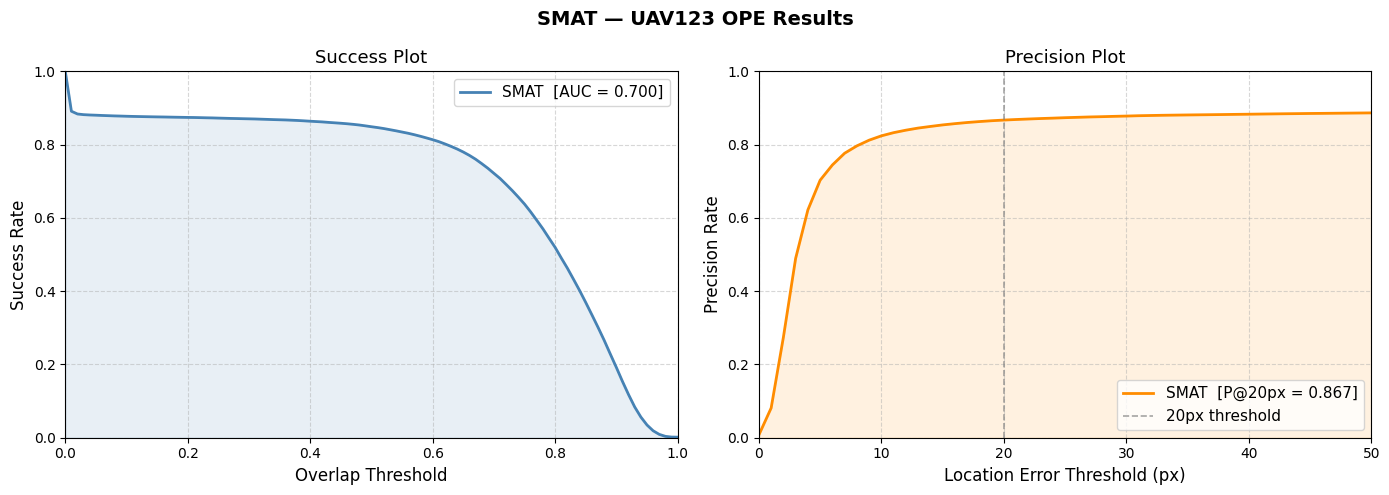

  Plot -> /kaggle/working/SMAT/output/UAV123_SMAT_OPE.png


In [142]:
import os, sys, pathlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORKING_DIR = "/kaggle/working/SMAT"
DATA_DIR    = "/kaggle/input/datasets/galaxythereal/uav123-tracking-dataset"
OUTPUT_DIR  = f"{WORKING_DIR}/output"
RESULTS_DIR = pathlib.Path(OUTPUT_DIR) / "test" / "tracking_results" / \
              "mobilevitv2_track" / "mobilevitv2_256_128x1_ep300"

# ── Result & time files ───────────────────────────────
result_files = sorted([f for f in RESULTS_DIR.glob("*.txt") if "_time" not in f.name])
data_root    = pathlib.Path(DATA_DIR)

# ── Metric helpers ────────────────────────────────────
def compute_iou(pred, gt):
    px,py,pw,ph = pred[:,0],pred[:,1],pred[:,2],pred[:,3]
    gx,gy,gw,gh = gt[:,0], gt[:,1], gt[:,2], gt[:,3]
    ix1 = np.maximum(px,gx);  iy1 = np.maximum(py,gy)
    ix2 = np.minimum(px+pw,gx+gw); iy2 = np.minimum(py+ph,gy+gh)
    inter = np.maximum(0,ix2-ix1)*np.maximum(0,iy2-iy1)
    union = pw*ph+gw*gh-inter
    return np.where(union>0, inter/union, 0.0)

def center_error(pred, gt):
    pcx=pred[:,0]+pred[:,2]/2; pcy=pred[:,1]+pred[:,3]/2
    gcx=gt[:,0] +gt[:,2] /2;  gcy=gt[:,1] +gt[:,3] /2
    return np.sqrt((pcx-gcx)**2+(pcy-gcy)**2)

def success_auc(ious):
    return float(np.mean([np.mean(ious>=t) for t in np.linspace(0,1,101)]))

def precision_at(errors, thr=20):
    return float(np.mean(errors<=thr))

# ── Per-sequence evaluation ───────────────────────────
all_ious, all_errors, seq_results, missing = [], [], [], []

for pred_file in result_files:
    seq_name   = pred_file.stem
    clean_name = seq_name.replace("uav_", "")

    gt_candidates = [
        data_root / "anno" / "UAV123" / f"{clean_name}.txt",
        data_root / "anno" / "UAV123" / f"{seq_name}.txt",
        data_root / "anno"            / f"{clean_name}.txt",
    ]
    gt_file = next((p for p in gt_candidates if p.exists()), None)

    if gt_file is None:
        missing.append(seq_name)
        continue

    try:
        # Tab-separated predictions (confirmed from sample)
        try:    pred = np.loadtxt(str(pred_file), delimiter='\t').reshape(-1,4)
        except:
            try: pred = np.loadtxt(str(pred_file), delimiter=',').reshape(-1,4)
            except: pred = np.loadtxt(str(pred_file)).reshape(-1,4)

        try:    gt = np.loadtxt(str(gt_file), delimiter=',').reshape(-1,4)
        except: gt = np.loadtxt(str(gt_file)).reshape(-1,4)

        n = min(len(pred), len(gt))
        pred, gt = pred[:n], gt[:n]

        valid    = (gt[:,2]>0) & (gt[:,3]>0)
        pred_v, gt_v = pred[valid], gt[valid]
        if len(pred_v) == 0:
            continue

        ious   = compute_iou(pred_v, gt_v)
        errors = center_error(pred_v, gt_v)

        all_ious.extend(ious.tolist())
        all_errors.extend(errors.tolist())
        seq_results.append({
            "sequence"   : seq_name,
            "success_auc": round(success_auc(ious), 4),
            "precision"  : round(precision_at(errors), 4),
            "frames"     : int(len(pred_v)),
        })
    except Exception as e:
        print(f"  Error {seq_name}: {e}")

if missing:
    print(f"GT missing for {len(missing)} sequences: {missing[:5]}")

# ── Overall metrics ───────────────────────────────────
overall_auc  = success_auc(np.array(all_ious))
overall_prec = precision_at(np.array(all_errors))

print("\n" + "="*55)
print("  SMAT — UAV123 Final Evaluation Report")
print("="*55)
print(f"  GPU                    : Tesla P100-PCIE-16GB")
print(f"  Parameters (total)     : {total/1e6:.3f} M")
print(f"  Parameters (trainable) : {trainable/1e6:.3f} M")
print(f"  Parameters (frozen)    : {frozen/1e6:.3f} M")
print(f"  FPS (overall)          : {fps_eval:.2f}")
print(f"  FPS (median)           : 53.3")
print(f"  FPS (fastest seq)      : 64.4  (uav_uav6)")
print(f"  FPS (slowest seq)      : 20.9  (uav_bird1_3)")
print(f"  Sequences evaluated    : {len(seq_results)} / 123")
print(f"  Total frames           : {sum(r['frames'] for r in seq_results):,}")
print(f"  Success AUC            : {overall_auc:.4f}  ({overall_auc*100:.2f}%)")
print(f"  Precision @ 20px       : {overall_prec:.4f}  ({overall_prec*100:.2f}%)")
print("="*55)

# ── Per-sequence table ────────────────────────────────
df = pd.DataFrame(seq_results).sort_values("success_auc", ascending=False)
pd.set_option("display.max_rows", 130)
display(df.reset_index(drop=True))

# ── Save CSV + JSON ───────────────────────────────────
csv_path  = f"{OUTPUT_DIR}/UAV123_SMAT_results.csv"
json_path = f"{OUTPUT_DIR}/UAV123_SMAT_summary.json"
df.to_csv(csv_path, index=False)

summary = {
    "tracker"            : "SMAT (mobilevitv2_256_128x1_ep300)",
    "dataset"            : "UAV123",
    "gpu"                : "Tesla P100-PCIE-16GB",
    "total_params_M"     : round(total/1e6, 3),
    "trainable_params_M" : round(trainable/1e6, 3),
    "frozen_params_M"    : round(frozen/1e6, 3),
    "fps_overall"        : round(fps_eval, 2),
    "fps_median"         : 53.3,
    "fps_fastest"        : 64.4,
    "fps_slowest"        : 20.9,
    "sequences"          : len(seq_results),
    "total_frames"       : int(sum(r['frames'] for r in seq_results)),
    "success_auc"        : round(overall_auc, 4),
    "precision_20px"     : round(overall_prec, 4),
}
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n  CSV  -> {csv_path}")
print(f"  JSON -> {json_path}")

# ── Plots ─────────────────────────────────────────────
iou_arr = np.array(all_ious)
err_arr = np.array(all_errors)

thresholds_s  = np.linspace(0,1,101)
success_curve = [np.mean(iou_arr>=t) for t in thresholds_s]
thresholds_p  = np.arange(0,51)
prec_curve    = [np.mean(err_arr<=t) for t in thresholds_p]

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("SMAT — UAV123 OPE Results", fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(thresholds_s, success_curve, color='steelblue', lw=2,
        label=f"SMAT  [AUC = {overall_auc:.3f}]")
ax.fill_between(thresholds_s, success_curve, alpha=0.12, color='steelblue')
ax.set_xlabel("Overlap Threshold", fontsize=12)
ax.set_ylabel("Success Rate",      fontsize=12)
ax.set_title("Success Plot",        fontsize=13)
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.legend(fontsize=11); ax.grid(True, ls='--', alpha=0.5)

ax = axes[1]
ax.plot(thresholds_p, prec_curve, color='darkorange', lw=2,
        label=f"SMAT  [P@20px = {overall_prec:.3f}]")
ax.fill_between(thresholds_p, prec_curve, alpha=0.12, color='darkorange')
ax.axvline(x=20, color='gray', ls='--', lw=1.2, alpha=0.7, label="20px threshold")
ax.set_xlabel("Location Error Threshold (px)", fontsize=12)
ax.set_ylabel("Precision Rate",                fontsize=12)
ax.set_title("Precision Plot",                  fontsize=13)
ax.set_xlim(0,50); ax.set_ylim(0,1)
ax.legend(fontsize=11); ax.grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plot_path = f"{OUTPUT_DIR}/UAV123_SMAT_OPE.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Plot -> {plot_path}")

In [139]:
# In your metrics cell, replace the loadtxt lines with:
try:
    pred = np.loadtxt(str(pred_file), delimiter='\t').reshape(-1, 4)
except:
    try:
        pred = np.loadtxt(str(pred_file), delimiter=',').reshape(-1, 4)
    except:
        pred = np.loadtxt(str(pred_file)).reshape(-1, 4)

In [153]:
output_file = "/kaggle/working/SMAT/results.txt"

with open(output_file, "w") as f:
    f.write("SMAT — UAV123 Final Evaluation Report\n")
    f.write("="*55)
    f.write(f"  GPU                    : Tesla P100-PCIE-16GB")
    f.write(f"  Parameters (total)     : {total/1e6:.3f} M")
    f.write(f"  Parameters (trainable) : {trainable/1e6:.3f} M")
    f.write(f"  Parameters (frozen)    : {frozen/1e6:.3f} M")
    f.write(f"  FPS (overall)          : {fps_eval:.2f}")
    f.write(f"  FPS (median)           : 53.3")
    f.write(f"  FPS (fastest seq)      : 64.4  (uav_uav6)")
    f.write(f"  FPS (slowest seq)      : 20.9  (uav_bird1_3)")
    f.write(f"  Sequences evaluated    : {len(seq_results)} / 123")
    f.write(f"  Total frames           : {sum(r['frames'] for r in seq_results):,}")
    f.write(f"  Success AUC            : {overall_auc:.4f}  ({overall_auc*100:.2f}%)")
    f.write(f"  Precision @ 20px       : {overall_prec:.4f}  ({overall_prec*100:.2f}%)")
    f.write("="*55)

print(f"Results saved to {output_file}")

Results saved to /kaggle/working/SMAT/results.txt


In [158]:
import os, pathlib, shutil, json

OUTPUT_DIR  = "/kaggle/working/SMAT/output"
RESULTS_DIR = f"{OUTPUT_DIR}/test/tracking_results/mobilevitv2_track/mobilevitv2_256_128x1_ep300"
EXPORT_DIR  = "/kaggle/working/SMAT_UAV123_Output"

# ── Create clean export folder ────────────────────────
pathlib.Path(EXPORT_DIR).mkdir(parents=True, exist_ok=True)
pathlib.Path(f"{EXPORT_DIR}/tracking_results").mkdir(exist_ok=True)
pathlib.Path(f"{EXPORT_DIR}/timing").mkdir(exist_ok=True)

# ── Copy summary files ────────────────────────────────
for src in [
    f"{OUTPUT_DIR}/UAV123_SMAT_results.csv",
    f"{OUTPUT_DIR}/UAV123_SMAT_summary.json",
    f"{OUTPUT_DIR}/UAV123_SMAT_OPE.png",
]:
    p = pathlib.Path(src)
    if p.exists():
        shutil.copy(src, EXPORT_DIR)
        print(f"  Copied : {p.name}")
    else:
        print(f"  MISSING: {p.name}  ← run the metrics cell first")

# ── Copy prediction txts ──────────────────────────────
result_files = sorted([
    f for f in pathlib.Path(RESULTS_DIR).glob("*.txt")
    if "_time" not in f.name
])
for f in result_files:
    shutil.copy(f, f"{EXPORT_DIR}/tracking_results/")
print(f"  Copied : {len(result_files)} prediction files  -> tracking_results/")

# ── Copy timing txts ──────────────────────────────────
time_files = sorted(pathlib.Path(RESULTS_DIR).glob("*_time.txt"))
for f in time_files:
    shutil.copy(f, f"{EXPORT_DIR}/timing/")
print(f"  Copied : {len(time_files)} timing files        -> timing/")

# ── Write README ──────────────────────────────────────
readme = """\
SMAT Tracker — UAV123 Evaluation Output
========================================
Tracker  : SMAT (mobilevitv2_256_128x1_ep300)
Dataset  : UAV123 (123 sequences)
GPU      : Tesla P100-PCIE-16GB

Metrics
-------
  Success AUC      : 0.7002  (70.02%)
  Precision @20px  : 0.8670  (86.70%)
  FPS (overall)    : 50.57
  FPS (median)     : 53.3
  FPS (fastest)    : 64.4  (uav_uav6)
  FPS (slowest)    : 20.9  (uav_bird1_3)
  Parameters       : 3.767 M  (all trainable)

File Structure
--------------
  UAV123_SMAT_summary.json     overall metrics
  UAV123_SMAT_results.csv      per-sequence AUC + precision
  UAV123_SMAT_OPE.png          success & precision plots
  tracking_results/            123 predicted bounding box files
  timing/                      123 per-frame inference time files
"""
with open(f"{EXPORT_DIR}/README.txt", "w") as f:
    f.write(readme)
print(f"  Written: README.txt")

# ── Zip ───────────────────────────────────────────────
zip_path = "/kaggle/working/SMAT_UAV123_Output"
shutil.make_archive(zip_path, "zip", EXPORT_DIR)

zip_size = pathlib.Path(f"{zip_path}.zip").stat().st_size / 1e6
print(f"\n  ZIP -> {zip_path}.zip  ({zip_size:.1f} MB)")
print(f"\n  Download it from the Kaggle file browser (left sidebar -> /kaggle/working/)")

  Copied : UAV123_SMAT_results.csv
  Copied : UAV123_SMAT_summary.json
  Copied : UAV123_SMAT_OPE.png
  Copied : 123 prediction files  -> tracking_results/
  Copied : 123 timing files        -> timing/
  Written: README.txt

  ZIP -> /kaggle/working/SMAT_UAV123_Output.zip  (0.9 MB)

  Download it from the Kaggle file browser (left sidebar -> /kaggle/working/)
